In [1]:
# Problema: Decidir cuánta energía generar con agua embalsada y cuánta con plantas térmicas en cada período, sabiendo que usar agua hoy reduce lo disponible para la demanda futura.
# El agua usada hoy no estara disponible manana: el embalse enlaza todas las decisiones en el tiempo.

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.figure import Figure
from IPython.display import display
from IPython import get_ipython
import pulp

data_dir = Path("../data")
submission_dir = Path("../submission")
get_ipython().run_line_magic("matplotlib", "inline")
plt.rcParams.update({"figure.dpi": 110, "font.size": 10})
display(["periods.csv", "hydro.csv", "thermal.csv"])

['periods.csv', 'hydro.csv', 'thermal.csv']

In [2]:
# Caso sintetico de planeacion electrica centralizada; no representa un sistema real.

periods = pd.read_csv(data_dir / "periods.csv")
hydro = pd.read_csv(data_dir / "hydro.csv")
thermal = pd.read_csv(data_dir / "thermal.csv")
display(periods, hydro, thermal)

,period,demand_mwh,inflow_hm3
0,1,100,3.0
1,2,120,2.5
2,3,150,1.5
3,4,180,1.0
4,5,150,2.0
5,6,110,2.5


,initial_storage_hm3,minimum_storage_hm3,maximum_storage_hm3,final_storage_min_hm3,mwh_per_hm3,maximum_generation_mwh
0,10,2,20,4,10,80


,plant_id,variable_cost_per_mwh,maximum_generation_mwh
0,T1,40,60
1,T2,90,100


In [3]:
# Verificamos que el caso este bien definido antes de decidir nada.

assert len(periods) == 6 and periods.period.is_unique
assert periods.demand_mwh.gt(0).all() and periods.inflow_hm3.ge(0).all()
assert len(hydro) == 1
assert (hydro.minimum_storage_hm3 < hydro.maximum_storage_hm3).all()
assert (hydro.initial_storage_hm3.between(hydro.minimum_storage_hm3, hydro.maximum_storage_hm3)).all()
assert (hydro.final_storage_min_hm3 >= hydro.minimum_storage_hm3).all()
assert (hydro.mwh_per_hm3 > 0).all() and (hydro.maximum_generation_mwh > 0).all()
assert len(thermal) == 2 and thermal.plant_id.is_unique
assert thermal.variable_cost_per_mwh.gt(0).all() and thermal.maximum_generation_mwh.gt(0).all()
print(f"{len(periods)} periodos; 1 embalse; {len(thermal)} plantas termicas.")

6 periodos; 1 embalse; 2 plantas termicas.


In [4]:
# Antes de decidir nada, el periodo 4 ya exige una reserva minima de agua.

max_thermal = thermal.maximum_generation_mwh.sum()
period4_demand = periods.loc[periods.period == 4, "demand_mwh"].iloc[0]
mandatory_hydro_mwh = period4_demand - max_thermal
mandatory_release_hm3 = mandatory_hydro_mwh / hydro.loc[0, "mwh_per_hm3"]
print(f"Demanda periodo 4: {period4_demand} MWh; capacidad termica maxima: {max_thermal} MWh.")
print(f"Hidro obligatorio en periodo 4: {mandatory_hydro_mwh} MWh = {mandatory_release_hm3} hm3.")
print("Preservar agua antes del periodo 4 no es opcional: es estructuralmente necesario.")

Demanda periodo 4: 180 MWh; capacidad termica maxima: 160 MWh.
Hidro obligatorio en periodo 4: 20 MWh = 2.0 hm3.
Preservar agua antes del periodo 4 no es opcional: es estructuralmente necesario.


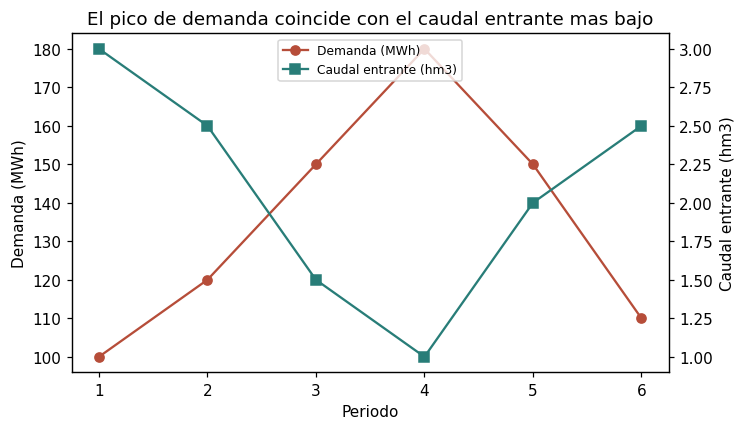

In [5]:
# La demanda y el caudal entrante no coinciden en el tiempo: ahi nace la necesidad de almacenar agua.

fig_frame, ax_frame = plt.subplots(figsize=(7, 4))
ax_frame.plot(periods.period, periods.demand_mwh, marker="o", color="#b64d39", label="Demanda (MWh)")
ax_frame2 = ax_frame.twinx()
ax_frame2.plot(periods.period, periods.inflow_hm3, marker="s", color="#287d78", label="Caudal entrante (hm3)")
ax_frame.set(
    xlabel="Periodo", ylabel="Demanda (MWh)",
    title="El pico de demanda coincide con el caudal entrante mas bajo",
)
ax_frame2.set_ylabel("Caudal entrante (hm3)")
lines1, labels1 = ax_frame.get_legend_handles_labels()
lines2, labels2 = ax_frame2.get_legend_handles_labels()
ax_frame.legend(lines1 + lines2, labels1 + labels2, loc="upper center", fontsize=8)
plt.show()

In [6]:
# Estructuras deterministas reutilizadas en heuristicas, modelo y validacion.

period_ids = periods.period.tolist()
demand = periods.set_index("period").demand_mwh.to_dict()
inflow = periods.set_index("period").inflow_hm3.to_dict()
thermal_ids = thermal.plant_id.tolist()
thermal_cost = thermal.set_index("plant_id").variable_cost_per_mwh.to_dict()
thermal_cap = thermal.set_index("plant_id").maximum_generation_mwh.to_dict()
storage_initial = float(hydro.loc[0, "initial_storage_hm3"])
storage_min = float(hydro.loc[0, "minimum_storage_hm3"])
storage_max = float(hydro.loc[0, "maximum_storage_hm3"])
storage_final_min = float(hydro.loc[0, "final_storage_min_hm3"])
mwh_per_hm3 = float(hydro.loc[0, "mwh_per_hm3"])
hydro_cap_mwh = float(hydro.loc[0, "maximum_generation_mwh"])
hydro_cap_hm3 = hydro_cap_mwh / mwh_per_hm3
print(f"Capacidad hidrica: {hydro_cap_mwh} MWh = {hydro_cap_hm3} hm3 por periodo.")

Capacidad hidrica: 80.0 MWh = 8.0 hm3 por periodo.


In [7]:
# Heuristica ingenua: usar la mayor cantidad de agua posible cada periodo, sin mirar el futuro.

def naive_hydro_first():
    s = storage_initial
    schedule = []
    infeasible_at = None
    for t in period_ids:
        avail_hm3 = max(0.0, s + inflow[t] - storage_min)
        demand_hm3_equiv = demand[t] / mwh_per_hm3
        release = min(hydro_cap_hm3, avail_hm3, demand_hm3_equiv)
        hydro_mwh = release * mwh_per_hm3
        remaining = demand[t] - hydro_mwh
        t1 = min(thermal_cap["T1"], remaining)
        remaining -= t1
        t2 = min(thermal_cap["T2"], remaining)
        remaining -= t2
        s_next = s + inflow[t] - release
        schedule.append(
            {
                "period": t, "release_hm3": release, "hydro_mwh": hydro_mwh,
                "T1_mwh": t1, "T2_mwh": t2, "storage_end_hm3": s_next, "unmet_mwh": remaining,
            }
        )
        s = s_next
        if remaining > 1e-6 and infeasible_at is None:
            infeasible_at = (t, remaining)
    return pd.DataFrame(schedule), infeasible_at

print("Politica ingenua definida: hidro primero, sin reserva para el futuro.")

Politica ingenua definida: hidro primero, sin reserva para el futuro.


In [8]:
# Usar agua libremente hoy puede volver el futuro infactible.

naive_schedule, naive_infeasible_at = naive_hydro_first()
display(naive_schedule)
if naive_infeasible_at is not None:
    t_fail, unmet = naive_infeasible_at
    print(f"INFACTIBLE en el periodo {t_fail}: demanda insatisfecha de {unmet:.1f} MWh.")
    print("El uso localmente barato del agua destruyo la factibilidad futura.")

,period,release_hm3,hydro_mwh,T1_mwh,T2_mwh,storage_end_hm3,unmet_mwh
0,1,8.0,80.0,20.0,0.0,5.0,0.0
1,2,5.5,55.0,60.0,5.0,2.0,0.0
2,3,1.5,15.0,60.0,75.0,2.0,0.0
3,4,1.0,10.0,60.0,100.0,2.0,10.0
4,5,2.0,20.0,60.0,70.0,2.0,0.0
5,6,2.5,25.0,60.0,25.0,2.0,0.0


INFACTIBLE en el periodo 4: demanda insatisfecha de 10.0 MWh.
El uso localmente barato del agua destruyo la factibilidad futura.


In [9]:
# Derivamos cuanta agua debe quedar disponible antes del periodo pico.

mandatory_release_p4 = mandatory_release_hm3
min_end_storage_p4 = storage_min
required_storage_end_p3 = min_end_storage_p4 + mandatory_release_p4 - inflow[4]
print(f"Hidro obligatorio periodo 4: {mandatory_release_p4} hm3.")
print(f"Caudal entrante periodo 4: {inflow[4]} hm3.")
print(f"Almacenamiento minimo al final del periodo 4: {min_end_storage_p4} hm3.")
print(f"Por lo tanto, almacenamiento requerido al final del periodo 3: {required_storage_end_p3} hm3.")

Hidro obligatorio periodo 4: 2.0 hm3.
Caudal entrante periodo 4: 1.0 hm3.
Almacenamiento minimo al final del periodo 4: 2.0 hm3.
Por lo tanto, almacenamiento requerido al final del periodo 3: 3.0 hm3.


In [10]:
# Regla factible: misma prioridad hidro-termica, pero con pisos de almacenamiento que protegen el pico.

end_of_period_floor = {
    1: storage_min,
    2: storage_min,
    3: required_storage_end_p3,
    4: storage_min,
    5: storage_min,
    6: storage_final_min,
}

def feasible_reserve_rule():
    s = storage_initial
    schedule = []
    infeasible_at = None
    for t in period_ids:
        floor = end_of_period_floor[t]
        avail_hm3 = max(0.0, s + inflow[t] - floor)
        demand_hm3_equiv = demand[t] / mwh_per_hm3
        release = min(hydro_cap_hm3, avail_hm3, demand_hm3_equiv)
        hydro_mwh = release * mwh_per_hm3
        remaining = demand[t] - hydro_mwh
        t1 = min(thermal_cap["T1"], remaining)
        remaining -= t1
        t2 = min(thermal_cap["T2"], remaining)
        remaining -= t2
        s_next = s + inflow[t] - release
        schedule.append(
            {
                "period": t, "release_hm3": release, "hydro_mwh": hydro_mwh,
                "T1_mwh": t1, "T2_mwh": t2, "storage_end_hm3": s_next, "unmet_mwh": remaining,
            }
        )
        s = s_next
        if remaining > 1e-6 and infeasible_at is None:
            infeasible_at = (t, remaining)
    return pd.DataFrame(schedule), infeasible_at

print("Regla factible definida: hidro-termica con pisos de almacenamiento por periodo.")

Regla factible definida: hidro-termica con pisos de almacenamiento por periodo.


In [11]:
# Verificamos que la regla factible cumpla la demanda en todos los periodos.

feasible_schedule, feasible_infeasible_at = feasible_reserve_rule()
assert feasible_infeasible_at is None
assert feasible_schedule.storage_end_hm3.iloc[-1] >= storage_final_min - 1e-9
feasible_rule_cost = float(
    (feasible_schedule.T1_mwh * thermal_cost["T1"] + feasible_schedule.T2_mwh * thermal_cost["T2"]).sum()
)
display(feasible_schedule)
print(f"Costo total de la regla factible: {feasible_rule_cost:,.0f}")

,period,release_hm3,hydro_mwh,T1_mwh,T2_mwh,storage_end_hm3,unmet_mwh
0,1,8.0,80.0,20.0,0.0,5.0,0.0
1,2,5.5,55.0,60.0,5.0,2.0,0.0
2,3,0.5,5.0,60.0,85.0,3.0,0.0
3,4,2.0,20.0,60.0,100.0,2.0,0.0
4,5,2.0,20.0,60.0,70.0,2.0,0.0
5,6,0.5,5.0,60.0,45.0,4.0,0.0


Costo total de la regla factible: 40,250


In [12]:
# Las variables de decision son continuas y estan enlazadas dinamicamente entre periodos.

print("Liberar agua en un periodo cambia el almacenamiento disponible en todos los periodos futuros.")
print("No existe un conjunto discreto y finito de decisiones para enumerar de forma transparente.")
print("La progresion correcta es: politica basada en reglas -> modelo matematico -> solver profesional.")

Liberar agua en un periodo cambia el almacenamiento disponible en todos los periodos futuros.
No existe un conjunto discreto y finito de decisiones para enumerar de forma transparente.
La progresion correcta es: politica basada en reglas -> modelo matematico -> solver profesional.


In [13]:
# MODEL
# ---------------------------------------------------------------------
# Sets:
#   t in PERIODS
#   g in THERMAL_PLANTS
#
# Parameters:
#   demand[t]                   MWh
#   inflow[t]                   hm3
#   thermal_cost[g]             monetary units / MWh
#   thermal_capacity[g]         MWh
#   hydro_capacity              MWh
#   mwh_per_hm3                 MWh / hm3
#   storage_initial             hm3
#   storage_min                 hm3
#   storage_max                 hm3
#   storage_final_min           hm3
#
# Decision variables:
#   thermal[g,t] >= 0           MWh
#   hydro[t] >= 0               MWh
#   release[t] >= 0             hm3
#   storage[t] >= 0             hm3
#   spill[t] >= 0                hm3
#
# Objective:
#   minimize operating_cost:
#       sum{g in THERMAL_PLANTS, t in PERIODS}
#           thermal_cost[g] * thermal[g,t]
#
# Constraints:
#   subject to demand_balance{t in PERIODS}:
#       hydro[t]
#       + sum{g in THERMAL_PLANTS} thermal[g,t]
#       = demand[t]
#
#   subject to hydro_conversion{t in PERIODS}:
#       hydro[t]
#       = mwh_per_hm3 * release[t]
#
#   subject to reservoir_balance{t in PERIODS}:
#       storage[t]
#       = previous_storage[t]
#       + inflow[t]
#       - release[t]
#       - spill[t]
#
#   subject to storage_bounds{t in PERIODS}:
#       storage_min <= storage[t] <= storage_max
#
#   subject to hydro_capacity{t in PERIODS}:
#       hydro[t] <= hydro_capacity
#
#   subject to thermal_capacity{g in THERMAL_PLANTS, t in PERIODS}:
#       thermal[g,t] <= thermal_capacity[g]
#
#   subject to terminal_storage:
#       storage[last] >= storage_final_min

display(pd.Series({"periods": len(period_ids), "thermal_plants": len(thermal_ids)}))
print("storage[t] es el almacenamiento al final del periodo t.")
print("Para t=1, previous_storage[1] = storage_initial; para t>1, previous_storage[t] = storage[t-1].")

periods           6
thermal_plants    2
dtype: int64

storage[t] es el almacenamiento al final del periodo t.
Para t=1, previous_storage[1] = storage_initial; para t>1, previous_storage[t] = storage[t-1].


In [14]:
# Construimos el mismo modelo con PuLP; HiGHS lo resolvera a continuacion.

model = pulp.LpProblem("hydrothermal_planning", pulp.LpMinimize)
thermal_var = {(g, t): pulp.LpVariable(f"thermal_{g}_{t}", lowBound=0) for g in thermal_ids for t in period_ids}
hydro_var = {t: pulp.LpVariable(f"hydro_{t}", lowBound=0) for t in period_ids}
release_var = {t: pulp.LpVariable(f"release_{t}", lowBound=0) for t in period_ids}
storage_var = {t: pulp.LpVariable(f"storage_{t}", lowBound=storage_min, upBound=storage_max) for t in period_ids}
spill_var = {t: pulp.LpVariable(f"spill_{t}", lowBound=0) for t in period_ids}

model += pulp.lpSum(thermal_cost[g] * thermal_var[(g, t)] for g in thermal_ids for t in period_ids)

reservoir_balance_names = {}
for t in period_ids:
    model += (hydro_var[t] == mwh_per_hm3 * release_var[t]), f"hydro_conversion_{t}"
    model += (
        hydro_var[t] + pulp.lpSum(thermal_var[(g, t)] for g in thermal_ids) == demand[t]
    ), f"demand_balance_{t}"
    previous_storage = storage_initial if t == 1 else storage_var[t - 1]
    cname = f"reservoir_balance_{t}"
    model += (storage_var[t] == previous_storage + inflow[t] - release_var[t] - spill_var[t]), cname
    reservoir_balance_names[t] = cname
    model += release_var[t] * mwh_per_hm3 <= hydro_cap_mwh, f"hydro_capacity_{t}"
    for g in thermal_ids:
        model += thermal_var[(g, t)] <= thermal_cap[g], f"thermal_capacity_{g}_{t}"
model += storage_var[period_ids[-1]] >= storage_final_min, "terminal_storage"

display(
    pd.Series(
        {
            "thermal_variables": len(thermal_var),
            "hydro_variables": len(hydro_var),
            "release_variables": len(release_var),
            "storage_variables": len(storage_var),
            "spill_variables": len(spill_var),
        }
    )
)

thermal_variables    12
hydro_variables       6
release_variables     6
storage_variables     6
spill_variables       6
dtype: int64

In [15]:
# Resolvemos el modelo lineal intertemporal con HiGHS.

solver = pulp.HiGHS(msg=False)
status = model.solve(solver)
assert pulp.LpStatus[status] == "Optimal"
optimized_cost = pulp.value(model.objective)
optimized_schedule = pd.DataFrame(
    [
        {
            "period": t,
            "release_hm3": release_var[t].value(),
            "hydro_mwh": hydro_var[t].value(),
            "T1_mwh": thermal_var[("T1", t)].value(),
            "T2_mwh": thermal_var[("T2", t)].value(),
            "storage_end_hm3": storage_var[t].value(),
            "spill_hm3": spill_var[t].value(),
        }
        for t in period_ids
    ]
)
display(optimized_schedule)
print(f"Estado: {pulp.LpStatus[status]}; costo optimo: {optimized_cost:,.2f}")

,period,release_hm3,hydro_mwh,T1_mwh,T2_mwh,storage_end_hm3,spill_hm3
0,1,3.5,35.0,60.0,5.0,9.5,0.0
1,2,-0.0,0.0,60.0,60.0,12.0,0.0
2,3,-0.0,0.0,60.0,90.0,13.5,0.0
3,4,2.0,20.0,60.0,100.0,12.5,0.0
4,5,8.0,80.0,60.0,10.0,6.5,0.0
5,6,5.0,50.0,60.0,0.0,4.0,0.0


Estado: Optimal; costo optimo: 38,250.00


In [16]:
# Validamos balances, limites y no negatividad de forma independiente.

for t in period_ids:
    row = optimized_schedule.loc[optimized_schedule.period == t].iloc[0]
    assert row.hydro_mwh >= -1e-6 and row.release_hm3 >= -1e-6 and row.spill_hm3 >= -1e-6
    assert np.isclose(row.hydro_mwh, mwh_per_hm3 * row.release_hm3)
    assert row.T1_mwh <= thermal_cap["T1"] + 1e-6 and row.T2_mwh <= thermal_cap["T2"] + 1e-6
    assert row.hydro_mwh <= hydro_cap_mwh + 1e-6
    assert storage_min - 1e-6 <= row.storage_end_hm3 <= storage_max + 1e-6
    assert np.isclose(row.hydro_mwh + row.T1_mwh + row.T2_mwh, demand[t])
    prev = (
        storage_initial if t == 1
        else optimized_schedule.loc[optimized_schedule.period == t - 1, "storage_end_hm3"].iloc[0]
    )
    assert np.isclose(row.storage_end_hm3, prev + inflow[t] - row.release_hm3 - row.spill_hm3)
assert optimized_schedule.storage_end_hm3.iloc[-1] >= storage_final_min - 1e-6
print("Validado: demanda, conversion hidrica, capacidades y balance de embalse consistentes en todos los periodos.")

Validado: demanda, conversion hidrica, capacidades y balance de embalse consistentes en todos los periodos.


In [17]:
# El objetivo recalculado debe coincidir con el del solver, y el optimo debe superar a la regla factible.

recomputed_cost = float(
    (optimized_schedule.T1_mwh * thermal_cost["T1"] + optimized_schedule.T2_mwh * thermal_cost["T2"]).sum()
)
assert np.isclose(recomputed_cost, optimized_cost)
assert optimized_cost <= feasible_rule_cost + 1e-6
print(f"Costo recalculado: {recomputed_cost:,.2f}; costo del solver: {optimized_cost:,.2f}")
print(f"Optimo <= regla factible: {optimized_cost:.2f} <= {feasible_rule_cost:.2f}")

Costo recalculado: 38,250.00; costo del solver: 38,250.00
Optimo <= regla factible: 38250.00 <= 40250.00


In [18]:
# El valor del agua es el costo sombra de una unidad adicional de almacenamiento inicial.

raw_dual = model.constraints[reservoir_balance_names[1]].pi
water_value_per_hm3 = -raw_dual
print(f"Dual crudo (reservoir_balance_1): {raw_dual:.2f}")
print("Mas agua inicial reduce el costo minimizado -> la derivada del objetivo es negativa.")
print(f"Valor economico del agua: {water_value_per_hm3:.2f} unidades monetarias / hm3")

Dual crudo (reservoir_balance_1): -900.00
Mas agua inicial reduce el costo minimizado -> la derivada del objetivo es negativa.
Valor economico del agua: 900.00 unidades monetarias / hm3


In [19]:
# Funcion reutilizable: resuelve el modelo completo con un almacenamiento inicial distinto.

def solve_hydrothermal(initial_storage_value):
    m = pulp.LpProblem("hydrothermal_planning_scenario", pulp.LpMinimize)
    th = {(g, t): pulp.LpVariable(f"th_{g}_{t}", lowBound=0) for g in thermal_ids for t in period_ids}
    hy = {t: pulp.LpVariable(f"hy_{t}", lowBound=0) for t in period_ids}
    rl = {t: pulp.LpVariable(f"rl_{t}", lowBound=0) for t in period_ids}
    st = {t: pulp.LpVariable(f"st_{t}", lowBound=storage_min, upBound=storage_max) for t in period_ids}
    sp = {t: pulp.LpVariable(f"sp_{t}", lowBound=0) for t in period_ids}
    m += pulp.lpSum(thermal_cost[g] * th[(g, t)] for g in thermal_ids for t in period_ids)
    balance_names = {}
    for t in period_ids:
        m += hy[t] == mwh_per_hm3 * rl[t]
        m += hy[t] + pulp.lpSum(th[(g, t)] for g in thermal_ids) == demand[t]
        previous_storage = initial_storage_value if t == 1 else st[t - 1]
        cname = f"balance_{t}"
        m += (st[t] == previous_storage + inflow[t] - rl[t] - sp[t]), cname
        balance_names[t] = cname
        m += rl[t] * mwh_per_hm3 <= hydro_cap_mwh
        for g in thermal_ids:
            m += th[(g, t)] <= thermal_cap[g]
    m += st[period_ids[-1]] >= storage_final_min
    solver_ = pulp.HiGHS(msg=False)
    status_ = m.solve(solver_)
    assert pulp.LpStatus[status_] == "Optimal"
    cost_ = pulp.value(m.objective)
    water_value_ = -m.constraints[balance_names[1]].pi
    total_hydro_ = sum(hy[t].value() for t in period_ids)
    total_t2_ = sum(th[("T2", t)].value() for t in period_ids)
    terminal_storage_ = st[period_ids[-1]].value()
    return cost_, water_value_, total_hydro_, total_t2_, terminal_storage_

print("Funcion de escenario definida: resuelve el modelo completo con un almacenamiento inicial distinto.")

Funcion de escenario definida: resuelve el modelo completo con un almacenamiento inicial distinto.


In [20]:
# Validamos el dual resolviendo de nuevo el modelo con una pequena perturbacion en el almacenamiento inicial.

delta = 0.1
perturbed_cost, _, _, _, _ = solve_hydrothermal(storage_initial + delta)
water_value_fd = (optimized_cost - perturbed_cost) / delta
assert np.isclose(water_value_per_hm3, water_value_fd, atol=1e-3)
print(f"Costo perturbado (+{delta} hm3): {perturbed_cost:,.2f}")
print(f"Valor del agua por diferencias finitas: {water_value_fd:.2f} unidades monetarias / hm3")
print(f"Coincide con el dual: {np.isclose(water_value_per_hm3, water_value_fd, atol=1e-3)}")

Costo perturbado (+0.1 hm3): 38,160.00
Valor del agua por diferencias finitas: 900.00 unidades monetarias / hm3
Coincide con el dual: True


In [21]:
# Interpretacion central: el agua vale lo que evita gastar en la planta termica mas cara.

implied_water_value = mwh_per_hm3 * thermal_cost["T2"]
assert np.isclose(implied_water_value, water_value_per_hm3)
print(f"1 hm3 produce {mwh_per_hm3:.0f} MWh; T2 cuesta {thermal_cost['T2']:.0f} / MWh.")
print(f"Un hm3 que desplaza generacion de T2 vale: {mwh_per_hm3:.0f} * {thermal_cost['T2']:.0f} = {implied_water_value:.0f} / hm3")
print("El agua tiene valor economico aunque no tenga costo variable explicito en el objetivo.")

1 hm3 produce 10 MWh; T2 cuesta 90 / MWh.
Un hm3 que desplaza generacion de T2 vale: 10 * 90 = 900 / hm3
El agua tiene valor economico aunque no tenga costo variable explicito en el objetivo.


In [22]:
# Comparamos unicamente las dos politicas factibles bajo el mismo criterio economico.

plan_comparison = pd.DataFrame(
    [
        ["feasible_peak_reserve_rule", feasible_rule_cost],
        ["optimized", optimized_cost],
    ],
    columns=["strategy", "operating_cost"],
)
plan_comparison["gap_vs_optimized"] = plan_comparison.operating_cost - optimized_cost
display(plan_comparison)
print(f"Ahorro del plan optimizado frente a la regla factible: {feasible_rule_cost - optimized_cost:,.0f}")

,strategy,operating_cost,gap_vs_optimized
0,feasible_peak_reserve_rule,40250.0,2000.0
1,optimized,38250.0,0.0


Ahorro del plan optimizado frente a la regla factible: 2,000


In [23]:
# Resolvemos el modelo completo para distintos niveles de almacenamiento inicial.

sensitivity_rows = []
for s0 in [2, 4, 6, 8, 10, 12, 14, 16, 18, 20]:
    cost_, wv_, hydro_total_, t2_total_, terminal_ = solve_hydrothermal(s0)
    sensitivity_rows.append([s0, cost_, wv_, hydro_total_, t2_total_, terminal_])
storage_sensitivity = pd.DataFrame(
    sensitivity_rows,
    columns=[
        "initial_storage_hm3", "optimal_operating_cost", "water_value_per_hm3",
        "total_hydro_generation_mwh", "total_T2_generation_mwh", "terminal_storage_hm3",
    ],
)
display(storage_sensitivity)

,initial_storage_hm3,optimal_operating_cost,water_value_per_hm3,total_hydro_generation_mwh,total_T2_generation_mwh,terminal_storage_hm3
0,2,45450.0,900.0,105.0,345.0,4.0
1,4,43650.0,900.0,125.0,325.0,4.0
2,6,41850.0,900.0,145.0,305.0,4.0
3,8,40050.0,900.0,165.0,285.0,4.0
4,10,38250.0,900.0,185.0,265.0,4.0
5,12,36450.0,900.0,205.0,245.0,4.0
6,14,34650.0,900.0,225.0,225.0,4.0
7,16,32850.0,900.0,245.0,205.0,4.0
8,18,31050.0,900.0,265.0,185.0,4.0
9,20,29250.0,900.0,285.0,165.0,4.0


In [24]:
# El valor del agua se mantiene constante porque T2 sigue siendo el recurso marginal en todo el rango.

assert storage_sensitivity.optimal_operating_cost.diff().dropna().lt(0).all()
assert np.allclose(storage_sensitivity.water_value_per_hm3, water_value_per_hm3, atol=1e-3)
print("El costo optimo cae de forma monotona al aumentar el almacenamiento inicial.")
print("El valor del agua permanece constante: T2 sigue siendo el recurso termico desplazado en todo el rango evaluado.")
print("No se ajustaron los datos para forzar un valor de agua variable: este es el resultado genuino del modelo.")

El costo optimo cae de forma monotona al aumentar el almacenamiento inicial.
El valor del agua permanece constante: T2 sigue siendo el recurso termico desplazado en todo el rango evaluado.
No se ajustaron los datos para forzar un valor de agua variable: este es el resultado genuino del modelo.


In [25]:
# Registramos el despacho optimizado por periodo.

generation_schedule = optimized_schedule[["period", "hydro_mwh", "T1_mwh", "T2_mwh"]].copy()
generation_schedule.insert(1, "demand_mwh", [demand[t] for t in generation_schedule.period])
display(generation_schedule)

,period,demand_mwh,hydro_mwh,T1_mwh,T2_mwh
0,1,100,35.0,60.0,5.0
1,2,120,0.0,60.0,60.0
2,3,150,0.0,60.0,90.0
3,4,180,20.0,60.0,100.0
4,5,150,80.0,60.0,10.0
5,6,110,50.0,60.0,0.0


In [26]:
# Registramos la trayectoria del embalse; el valor del agua es un escalar, no una serie por periodo.

reservoir_schedule = optimized_schedule[["period", "release_hm3", "spill_hm3", "storage_end_hm3"]].copy()
reservoir_schedule.insert(1, "inflow_hm3", [inflow[t] for t in reservoir_schedule.period])
reservoir_schedule = reservoir_schedule.rename(columns={"storage_end_hm3": "storage_hm3"})
display(reservoir_schedule)

,period,inflow_hm3,release_hm3,spill_hm3,storage_hm3
0,1,3.0,3.5,0.0,9.5
1,2,2.5,-0.0,0.0,12.0
2,3,1.5,-0.0,0.0,13.5
3,4,1.0,2.0,0.0,12.5
4,5,2.0,8.0,0.0,6.5
5,6,2.5,5.0,0.0,4.0


In [27]:
# Construimos el tablero sin mostrarlo hasta completar los cuatro paneles.

dashboard = Figure(figsize=(13, 9), layout="constrained")
grid = dashboard.add_gridspec(2, 2)
ax_mix = dashboard.add_subplot(grid[0, 0])
ax_reservoir = dashboard.add_subplot(grid[0, 1])
ax_t2 = dashboard.add_subplot(grid[1, 0])
ax_summary = dashboard.add_subplot(grid[1, 1])

In [28]:
# Panel 1: composicion de la generacion por periodo frente a la demanda.

ax_mix.bar(generation_schedule.period, generation_schedule.hydro_mwh, label="Hidro", color="#287d78")
ax_mix.bar(
    generation_schedule.period, generation_schedule.T1_mwh, bottom=generation_schedule.hydro_mwh,
    label="T1", color="#8299ad",
)
bottom_t2 = generation_schedule.hydro_mwh + generation_schedule.T1_mwh
ax_mix.bar(generation_schedule.period, generation_schedule.T2_mwh, bottom=bottom_t2, label="T2", color="#b64d39")
ax_mix.plot(generation_schedule.period, generation_schedule.demand_mwh, color="black", marker="o", label="Demanda")
ax_mix.set(xlabel="Periodo", ylabel="MWh", title="Mezcla de generacion vs. demanda")
ax_mix.legend(fontsize=8);

In [29]:
# Panel 2: trayectoria del embalse frente a sus limites operativos.

ax_reservoir.plot(
    reservoir_schedule.period, reservoir_schedule.storage_hm3, marker="o", color="#287d78", label="Almacenamiento"
)
ax_reservoir.axhline(storage_min, color="#b64d39", linestyle="--", linewidth=1, label="Minimo")
ax_reservoir.axhline(storage_final_min, color="#b48b47", linestyle=":", linewidth=1.5, label="Requisito final")
ax_reservoir.set(
    xlabel="Periodo", ylabel="Almacenamiento (hm3)",
    title="Trayectoria del embalse: acumula antes del pico, drena despues",
)
ax_reservoir.legend(fontsize=8);

In [30]:
# Panel 3: activacion de generacion termica cara. Panel 4: resumen de la decision.

ax_t2.bar(generation_schedule.period, generation_schedule.T2_mwh, color="#b64d39")
ax_t2.set(xlabel="Periodo", ylabel="T2 (MWh)", title="Generacion termica cara (T2) por periodo")

ax_summary.axis("off")
summary_text = (
    f"Costo optimizado: {optimized_cost:,.0f}\n"
    f"Costo regla factible: {feasible_rule_cost:,.0f}\n"
    f"Ahorro: {feasible_rule_cost - optimized_cost:,.0f}\n\n"
    f"Almacenamiento inicial: {storage_initial:.1f} hm3\n"
    f"Almacenamiento final: {optimized_schedule.storage_end_hm3.iloc[-1]:.1f} hm3\n\n"
    f"Valor del agua (dual): {water_value_per_hm3:.0f} / hm3\n"
    f"Valor del agua (dif. finitas): {water_value_fd:.0f} / hm3"
)
ax_summary.text(0.02, 0.98, summary_text, transform=ax_summary.transAxes, va="top", fontsize=11);

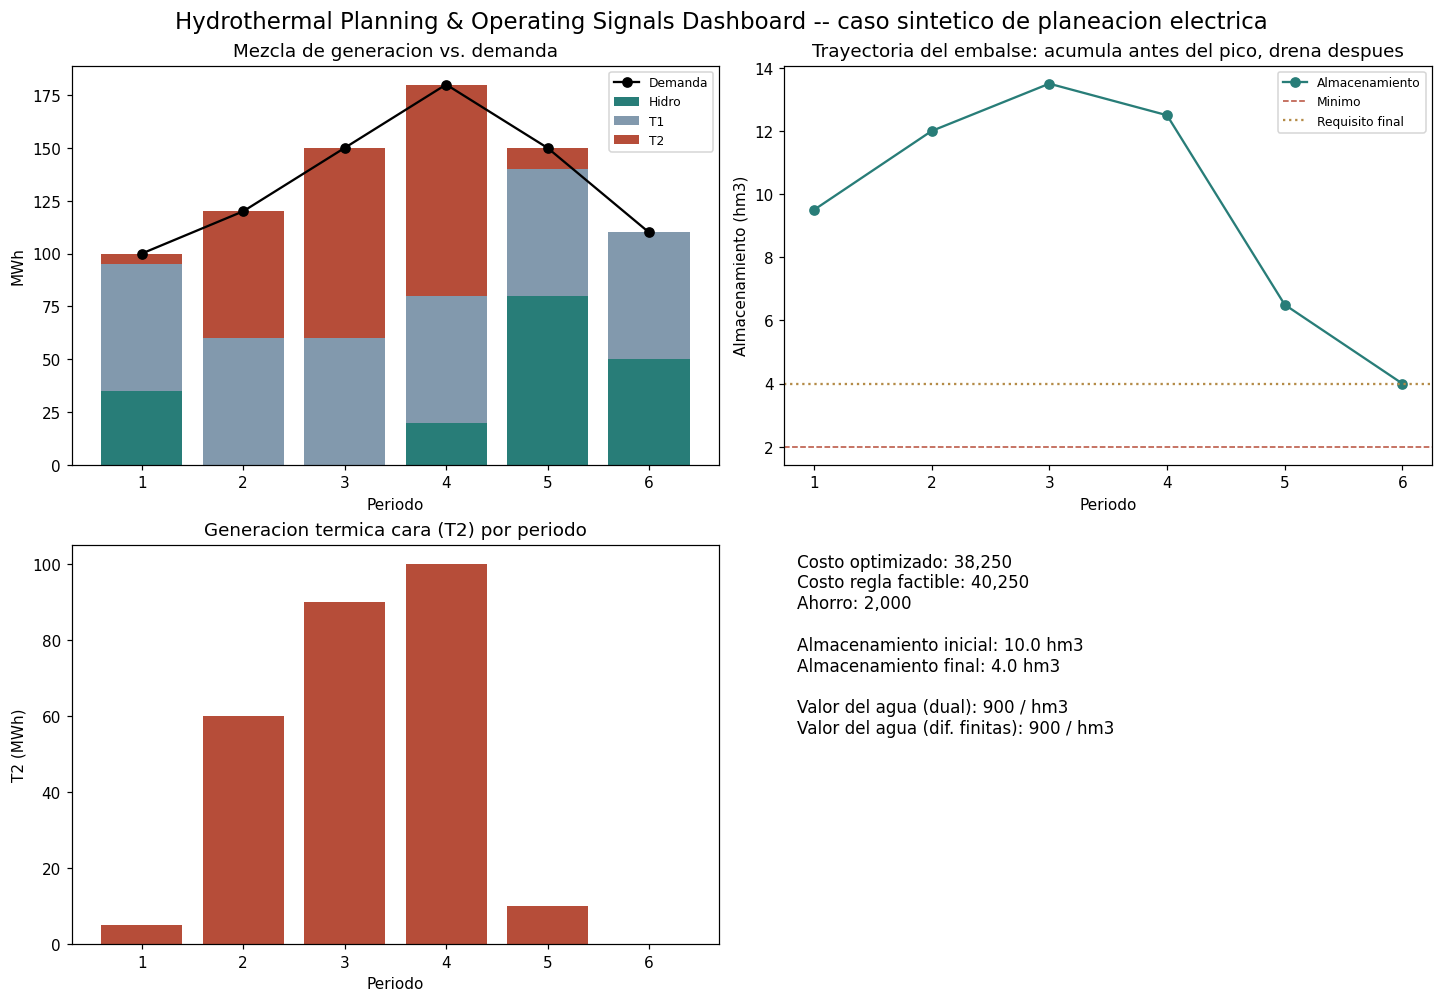

In [31]:
# El tablero completo es el producto de decision: cuando usar hidro, cuando conservar agua y cuanto vale.

dashboard.suptitle(
    "Hydrothermal Planning & Operating Signals Dashboard -- caso sintetico de planeacion electrica",
    fontsize=15,
)
display(dashboard)

In [32]:
# Verificamos el caso completo antes de generar los artefactos de entrega.

assert naive_infeasible_at is not None
assert naive_infeasible_at[0] == 4
assert np.isclose(naive_infeasible_at[1], 10.0)
assert feasible_infeasible_at is None
assert np.isclose(feasible_rule_cost, 40250)
assert pulp.LpStatus[status] == "Optimal"
assert np.isclose(optimized_cost, 38250)
assert np.isclose(feasible_rule_cost - optimized_cost, 2000)
assert np.isclose(optimized_schedule.storage_end_hm3.iloc[-1], 4.0)
assert np.isclose(optimized_schedule.spill_hm3.sum(), 0.0)
assert np.isclose(raw_dual, -900, atol=1e-3)
assert np.isclose(water_value_per_hm3, 900, atol=1e-3)
assert np.isclose(water_value_fd, 900, atol=1e-3)
assert np.isclose(water_value_per_hm3, water_value_fd, atol=1e-3)
assert np.allclose(
    storage_sensitivity.optimal_operating_cost.tolist(),
    [45450, 43650, 41850, 40050, 38250, 36450, 34650, 32850, 31050, 29250],
)
assert np.allclose(storage_sensitivity.water_value_per_hm3, 900, atol=1e-3)
print("Verificado: politicas de referencia, optimo HiGHS, valor del agua y sensibilidad consistentes con el caso aprobado.")

Verificado: politicas de referencia, optimo HiGHS, valor del agua y sensibilidad consistentes con el caso aprobado.


In [33]:
# Guardamos los cronogramas, la comparacion de planes y el tablero; no se vuelve a mostrar.

submission_dir.mkdir(exist_ok=True)
generation_schedule.to_csv(submission_dir / "generation_schedule.csv", index=False)
reservoir_schedule.to_csv(submission_dir / "reservoir_schedule.csv", index=False)
plan_comparison.to_csv(submission_dir / "plan_comparison.csv", index=False)
dashboard.savefig(
    submission_dir / "hydrothermal_planning_dashboard.png", dpi=180, bbox_inches="tight", facecolor="white"
)
display(
    [
        str(submission_dir / name)
        for name in [
            "generation_schedule.csv",
            "reservoir_schedule.csv",
            "plan_comparison.csv",
            "hydrothermal_planning_dashboard.png",
        ]
    ]
)

['../submission/generation_schedule.csv',
 '../submission/reservoir_schedule.csv',
 '../submission/plan_comparison.csv',
 '../submission/hydrothermal_planning_dashboard.png']